# Methodology Validation

This notebook validates the frozen experimental dataset
`data/final/unified_final_v1.parquet` against the dataset composition,
annotation semantics, and split configuration reported in the thesis.

It is a validation notebook and does not reconstruct the preprocessing
pipeline from the raw corpora.


In [8]:
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# CONFIG
# ============================================================

cwd = Path.cwd()

if (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the data/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "final" / "unified_final_v1.parquet"

OUTPUT_DIR = PROJECT_ROOT / "reports" / "methodology_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = [
    "hate_speech",
    "toxic",
    "threat",
    "insult",
]

EXPECTED_SOURCE_COUNTS = {
    "GMHP7k": 7_206,
    "HOCON34k": 34_260,
    "Gutefrage": 18_179,
    "RP-Mod": 28_685,
    "Jigsaw": 216_685,
    "Detox": 111_347,
    "Wikipedia Attacks": 36_880,
}

EXPECTED_TOTAL = 453_242
EXPECTED_GOLD = 88_330
EXPECTED_SILVER = 364_912

EXPECTED_SPLITS = {
    "train": 426_742,
    "val": 13_250,
    "test": 13_250,
}


# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_parquet(DATA_PATH)

print("=" * 70)
print("DATASET LOADED")
print("=" * 70)
print(f"Path: {DATA_PATH}")
print(f"Shape: {df.shape}")

print("\nColumns:")
print(df.columns.tolist())

print("\nSource values:")
print(df["source"].value_counts(dropna=False))


DATASET LOADED
Path: /Users/anhdang/PycharmProjects/netiquette-multilabel-classification/data/final/unified_final_v1.parquet
Shape: (453242, 12)

Columns:
['text', 'source', 'language', 'split', 'hate_speech', 'toxic', 'threat', 'insult', 'is_gold', 'data_quality', 'labse_score', 'qualitaet']

Source values:
source
jigsaw               216685
detox                111347
wikipedia_attacks     36880
hocon34k              34260
rp_mod                28685
gutefrage             18179
gmhp7k                 7206
Name: count, dtype: int64


## 1. Dataset Composition

Validate the total number of instances and the per-source counts of the
frozen final dataset.


In [9]:
def canonical_source(source):
    """
    Map internal source names to the names used in the thesis.
    """
    if pd.isna(source):
        return "UNKNOWN"

    s = str(source).lower().strip()

    if "gmhp" in s:
        return "GMHP7k"

    if "hocon" in s:
        return "HOCON34k"

    if "gutefrage" in s:
        return "Gutefrage"

    if "rp-mod" in s or "rp_mod" in s or "rpmod" in s:
        return "RP-Mod"

    if "jigsaw" in s:
        return "Jigsaw"

    if "detox" in s:
        return "Detox"

    if (
        "wikipedia_attacks" in s
        or "wikipedia attacks" in s
        or "wiki_attack" in s
    ):
        return "Wikipedia Attacks"

    return str(source)


df["source_thesis"] = df["source"].apply(canonical_source)

print(
    df["source_thesis"]
    .value_counts(dropna=False)
    .sort_index()
)

source_thesis
Detox                111347
GMHP7k                 7206
Gutefrage             18179
HOCON34k              34260
Jigsaw               216685
RP-Mod                28685
Wikipedia Attacks     36880
Name: count, dtype: int64


In [10]:
source_counts = (
    df.groupby("source_thesis")
      .size()
      .rename("actual")
      .reset_index()
      .rename(columns={"source_thesis": "dataset"})
)

source_counts["expected"] = (
    source_counts["dataset"]
    .map(EXPECTED_SOURCE_COUNTS)
)

source_counts["difference"] = (
    source_counts["actual"]
    - source_counts["expected"]
)

source_counts["matches_thesis"] = (
    source_counts["difference"] == 0
)

print("\n" + "=" * 70)
print("TABLE 4.1 VALIDATION")
print("=" * 70)

print(source_counts.to_string(index=False))


TABLE 4.1 VALIDATION
          dataset  actual  expected  difference  matches_thesis
            Detox  111347    111347           0            True
           GMHP7k    7206      7206           0            True
        Gutefrage   18179     18179           0            True
         HOCON34k   34260     34260           0            True
           Jigsaw  216685    216685           0            True
           RP-Mod   28685     28685           0            True
Wikipedia Attacks   36880     36880           0            True


In [11]:
assert len(df) == EXPECTED_TOTAL, (
    f"Final dataset mismatch: "
    f"expected {EXPECTED_TOTAL:,}, found {len(df):,}"
)

for source, expected in EXPECTED_SOURCE_COUNTS.items():

    actual = int(
        (df["source_thesis"] == source).sum()
    )

    assert actual == expected, (
        f"{source}: expected {expected:,}, "
        f"found {actual:,}"
    )

print("\n✓ All dataset counts match Section 4.1.")


✓ All dataset counts match Section 4.1.


## 2. Gold and Silver Composition

Validate the separation between authentic German gold data and
machine-translated silver data.


In [12]:
GOLD_SOURCES = {
    "GMHP7k",
    "HOCON34k",
    "Gutefrage",
    "RP-Mod",
}

df["gold_silver_derived"] = np.where(
    df["source_thesis"].isin(GOLD_SOURCES),
    "Gold",
    "Silver"
)

gold_silver_counts = (
    df["gold_silver_derived"]
    .value_counts()
)

print("\n" + "=" * 70)
print("GOLD / SILVER VALIDATION")
print("=" * 70)

print(gold_silver_counts)

actual_gold = int(
    (df["gold_silver_derived"] == "Gold").sum()
)

actual_silver = int(
    (df["gold_silver_derived"] == "Silver").sum()
)

assert actual_gold == EXPECTED_GOLD
assert actual_silver == EXPECTED_SILVER

print(f"\n✓ Gold:   {actual_gold:,}")
print(f"✓ Silver: {actual_silver:,}")
print(f"✓ Total:  {actual_gold + actual_silver:,}")


GOLD / SILVER VALIDATION
gold_silver_derived
Silver    364912
Gold       88330
Name: count, dtype: int64

✓ Gold:   88,330
✓ Silver: 364,912
✓ Total:  453,242


## 3. Annotation Coverage

Missing label annotations are represented by `NaN` and must not be
interpreted as negative examples.


In [13]:
records = []

for source in EXPECTED_SOURCE_COUNTS:

    subset = df[df["source_thesis"] == source]

    for label in LABELS:

        values = subset[label]

        total = len(values)
        missing = int(values.isna().sum())
        annotated = int(values.notna().sum())

        positive = int((values == 1).sum())
        negative = int((values == 0).sum())

        coverage = (
            annotated / total
            if total > 0
            else np.nan
        )

        records.append({
            "dataset": source,
            "label": label,
            "total": total,
            "annotated": annotated,
            "missing_nan": missing,
            "negative_0": negative,
            "positive_1": positive,
            "annotation_coverage": coverage,
        })


annotation_stats = pd.DataFrame(records)

print("\n" + "=" * 70)
print("ANNOTATION COVERAGE")
print("=" * 70)

print(annotation_stats.to_string(index=False))


ANNOTATION COVERAGE
          dataset       label  total  annotated  missing_nan  negative_0  positive_1  annotation_coverage
           GMHP7k hate_speech   7206       7206            0        5580        1626                  1.0
           GMHP7k       toxic   7206          0         7206           0           0                  0.0
           GMHP7k      threat   7206          0         7206           0           0                  0.0
           GMHP7k      insult   7206          0         7206           0           0                  0.0
         HOCON34k hate_speech  34260      34260            0       29020        5240                  1.0
         HOCON34k       toxic  34260          0        34260           0           0                  0.0
         HOCON34k      threat  34260          0        34260           0           0                  0.0
         HOCON34k      insult  34260          0        34260           0           0                  0.0
        Gutefrage hate_sp

In [14]:
print("\n" + "=" * 70)
print("LABEL VALUE VALIDATION")
print("=" * 70)

for label in LABELS:

    unique_values = set(
        df[label]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"{label}: {unique_values}")

    assert unique_values.issubset({0, 1, 0.0, 1.0}), (
        f"Unexpected values in {label}: "
        f"{unique_values}"
    )

print("\n✓ All labels contain only 0, 1 or NaN.")


LABEL VALUE VALIDATION
hate_speech: {0.0, 1.0}
toxic: {0.0, 1.0}
threat: {0.0, 1.0}
insult: {0.0, 1.0}

✓ All labels contain only 0, 1 or NaN.


In [15]:
coverage_matrix = (
    annotation_stats
    .pivot(
        index="dataset",
        columns="label",
        values="annotation_coverage"
    )
    .reindex(EXPECTED_SOURCE_COUNTS.keys())
    [LABELS]
)

print("\nAnnotation coverage:")
print(
    (coverage_matrix * 100)
    .round(1)
    .astype(str)
    + "%"
)


Annotation coverage:
label             hate_speech   toxic  threat  insult
dataset                                              
GMHP7k                 100.0%    0.0%    0.0%    0.0%
HOCON34k               100.0%    0.0%    0.0%    0.0%
Gutefrage              100.0%  100.0%    0.0%  100.0%
RP-Mod                 100.0%    0.0%  100.0%  100.0%
Jigsaw                 100.0%  100.0%  100.0%  100.0%
Detox                    0.0%  100.0%    0.0%    0.0%
Wikipedia Attacks        0.0%    0.0%    0.0%  100.0%


In [16]:
table_4_1 = source_counts[
    [
        "dataset",
        "actual",
        "expected",
        "difference",
        "matches_thesis",
    ]
].copy()

table_4_1.to_csv(
    OUTPUT_DIR / "table_4_1_dataset_counts.csv",
    index=False
)

print(
    f"Saved: "
    f"{OUTPUT_DIR / 'table_4_1_dataset_counts.csv'}"
)

Saved: /Users/anhdang/PycharmProjects/netiquette-multilabel-classification/reports/methodology_validation/table_4_1_dataset_counts.csv


In [17]:
annotation_stats.to_csv(
    OUTPUT_DIR / "table_4_2_annotation_coverage.csv",
    index=False
)

coverage_matrix.to_csv(
    OUTPUT_DIR / "table_4_2_coverage_matrix.csv"
)

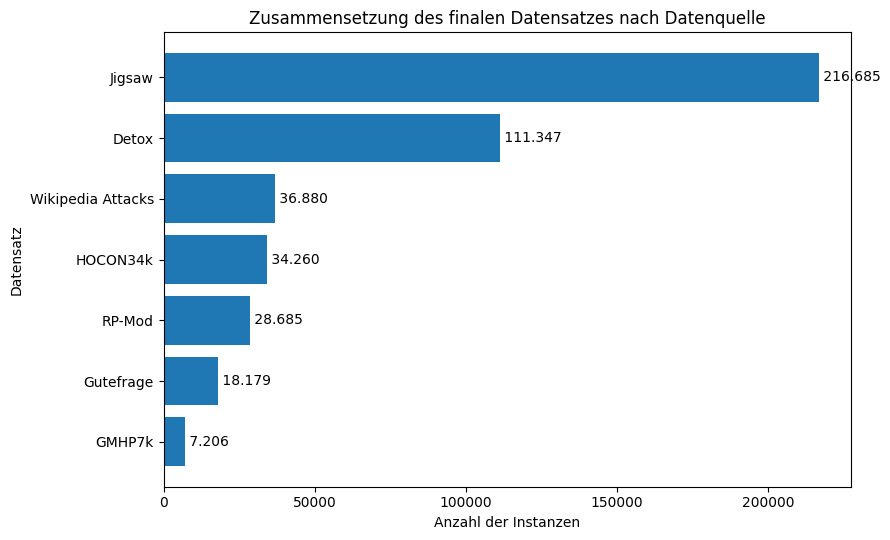

In [18]:
plot_counts = (
    df["source_thesis"]
    .value_counts()
    .reindex(EXPECTED_SOURCE_COUNTS.keys())
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.barh(
    plot_counts.index,
    plot_counts.values
)

ax.set_xlabel("Anzahl der Instanzen")
ax.set_ylabel("Datensatz")
ax.set_title(
    "Zusammensetzung des finalen Datensatzes nach Datenquelle"
)

for i, value in enumerate(plot_counts.values):
    ax.text(
        value,
        i,
        f" {value:,}".replace(",", "."),
        va="center"
    )

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "fig_dataset_sizes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

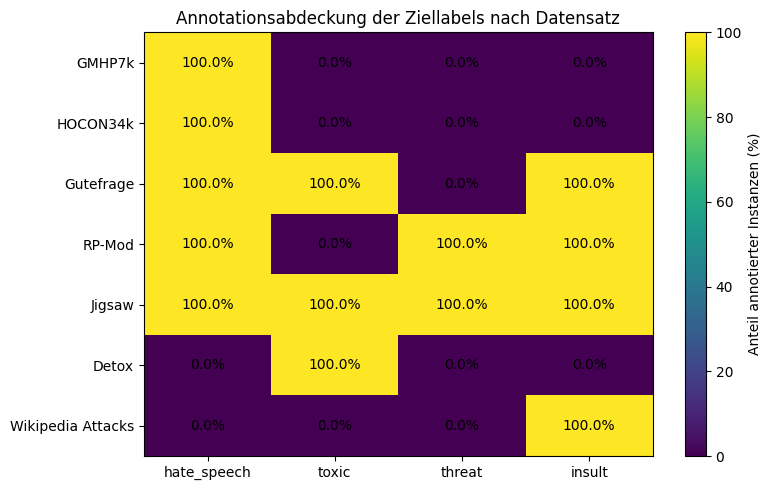

In [19]:
matrix = coverage_matrix * 100

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    matrix.values,
    aspect="auto"
)

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels(matrix.columns)

ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index)

ax.set_title(
    "Annotationsabdeckung der Ziellabels nach Datensatz"
)

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):

        value = matrix.iloc[i, j]

        if pd.notna(value):
            text = f"{value:.1f}%"
        else:
            text = "n/a"

        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center"
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Anteil annotierter Instanzen (%)")

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "fig_annotation_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
label_status = []

for label in LABELS:

    values = df[label]

    label_status.append({
        "label": label,
        "Positive (1)": int((values == 1).sum()),
        "Negative (0)": int((values == 0).sum()),
        "Missing (NaN)": int(values.isna().sum()),
    })

label_status = (
    pd.DataFrame(label_status)
    .set_index("label")
)

print(label_status)

             Positive (1)  Negative (0)  Missing (NaN)
label                                                 
hate_speech         11481        293534         148227
toxic               36574        309637         107031
threat                777        244593         207872
insult              21964        278465         152813


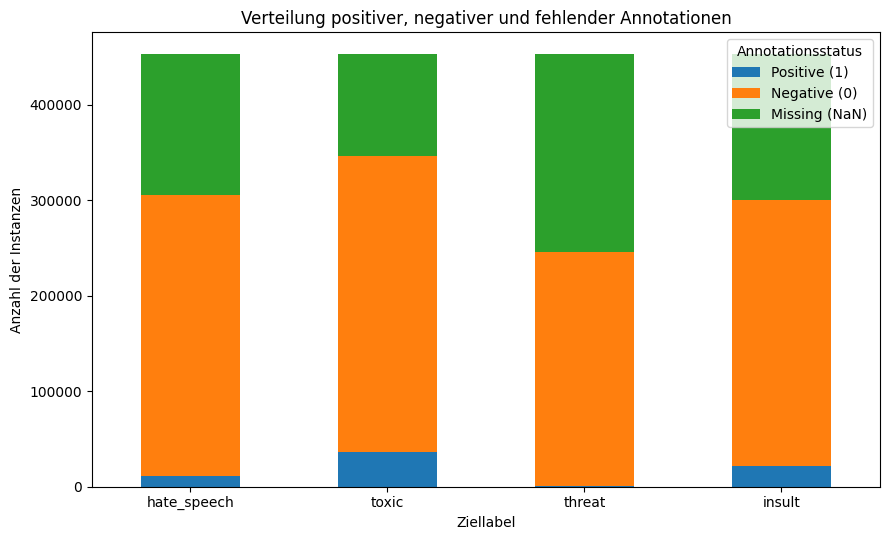

In [21]:
ax = label_status.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5.5)
)

ax.set_xlabel("Ziellabel")
ax.set_ylabel("Anzahl der Instanzen")
ax.set_title(
    "Verteilung positiver, negativer und fehlender Annotationen"
)

ax.legend(
    title="Annotationsstatus"
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "fig_label_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Split Validation

Validate the final train/validation/test distribution and ensure that
silver data occurs only in the training split.


In [22]:
print("\n" + "=" * 70)
print("SPLIT VALIDATION")
print("=" * 70)

split_counts = df["split"].value_counts()

print(split_counts)

for split, expected in EXPECTED_SPLITS.items():

    actual = int(split_counts.get(split, 0))

    assert actual == expected, (
        f"{split}: expected {expected:,}, "
        f"found {actual:,}"
    )

print("\n✓ Train / val / test counts validated.")


SPLIT VALIDATION
split
train    426742
test      13250
val       13250
Name: count, dtype: int64

✓ Train / val / test counts validated.


In [23]:
silver_eval = df[
    (df["gold_silver_derived"] == "Silver")
    & (df["split"].isin(["val", "test"]))
]

assert len(silver_eval) == 0, (
    f"ERROR: {len(silver_eval)} Silver instances "
    f"found in val/test."
)

print(
    "✓ No Silver instances found in "
    "validation or test set."
)

✓ No Silver instances found in validation or test set.


## 5. Validation Summary

Export the validation summary for the frozen experimental dataset.


In [24]:
summary = {
    "final_total": int(len(df)),

    "gold": actual_gold,
    "silver": actual_silver,

    "sources": {
        source: int(
            (df["source_thesis"] == source).sum()
        )
        for source in EXPECTED_SOURCE_COUNTS
    },

    "splits": {
        split: int(count)
        for split, count
        in df["split"].value_counts().items()
    },

    "labels": {}
}


for label in LABELS:

    values = df[label]

    summary["labels"][label] = {
        "annotated": int(values.notna().sum()),
        "missing": int(values.isna().sum()),
        "positive": int((values == 1).sum()),
        "negative": int((values == 0).sum()),
    }


with open(
    OUTPUT_DIR / "validation_summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


print(
    "\nValidation summary saved to:",
    OUTPUT_DIR / "validation_summary.json"
)


Validation summary saved to: /Users/anhdang/PycharmProjects/netiquette-multilabel-classification/reports/methodology_validation/validation_summary.json
